# FedX-PALM: Federated Learning Simulation (4 Clients + DP + XAI)

**Master's Thesis - Rachma Dianty (201012420007)** · Telkom University, 2026

---

## Tujuan
Notebook ini menjalankan **simulasi Federated Learning** sesuai inti tesis FedX-Palm:

1. **4 client node** dengan split Non-IID Dirichlet (α = 0.1, 0.3, 0.5, 0.7)
2. **FedAvg** weighted by client sample count
3. **Differential Privacy** (DP-FedAvg — clipping + Gaussian noise pada Δw)
4. **4 skenario ε** (baseline / weak 8.0 / moderate 4.0 / strong 1.0)
5. **Grad-CAM++ + Average Drop + FRR** pada model final
6. Plot **privacy-utility trade-off**

## Prerequisite
Notebook ini **butuh `best.pt`** dari notebook centralized sebelumnya yang sudah tersimpan di Drive (`/content/drive/MyDrive/fedx-palm/centralized_baseline/best.pt`). Kalau belum ada, jalankan dulu `fedx_palm_centralized_training.ipynb`.

## Catatan implementasi DP
Tesis Bab 3.4 menyebut Opacus DP-SGD untuk per-sample gradient noise. Namun **Opacus tidak kompatibel langsung dengan Ultralytics YOLOv11** (BatchNorm + mosaic + closed trainer). Implementasi di sini pakai **DP-FedAvg** (McMahan et al. 2018) — clipping + Gaussian noise pada *delta weight per klien*. Secara matematis tetap memberikan (ε, δ)-DP guarantee di level user/round, dan ini approach yang umum dipakai di FL+detection literatur.

## 1. Setup environment

In [1]:
!pip install -q ultralytics==8.4.51 roboflow grad-cam pyyaml opencv-python-headless seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.1 MB/s eta 0:00:00


In [2]:
import torch, ultralytics, roboflow
from ultralytics import YOLO
print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
    print(f'VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Ultralytics : {ultralytics.__version__}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch     : 2.10.0+cu128
CUDA        : True
GPU         : Tesla T4
VRAM        : 15.6 GB
Ultralytics : 8.4.51


## 2. Mount Drive & load baseline weight

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
BASELINE_W0 = '/content/drive/MyDrive/fedx-palm/centralized_baseline/best.pt'
assert os.path.exists(BASELINE_W0), f'best.pt tidak ditemukan di {BASELINE_W0} — jalankan notebook centralized dulu'

# Copy ke /content untuk akses cepat
W0_LOCAL = '/content/w0.pt'
shutil.copy2(BASELINE_W0, W0_LOCAL)
print(f'Initial weight w0: {W0_LOCAL} ({os.path.getsize(W0_LOCAL)//1024} KB)')

Mounted at /content/drive
Initial weight w0: /content/w0.pt (5345 KB)


## 3. Download dataset Roboflow

In [4]:
from roboflow import Roboflow
rf = Roboflow(api_key='Ej0bSMpeSri3ky0IYkOU')
project = rf.workspace('dydy-worker').project('palm-fruit-ripeness-detection-f6sac-ccb2z')
version = project.version(2)
dataset = version.download('yolov11', location='/content/data/palm_v2')
RAW_DIR = dataset.location
print(f'Dataset: {RAW_DIR}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/data/palm_v2 in yolov11:: 100%|██████████| 21640/21640 [00:04<00:00, 4480.30it/s]


Dataset: /content/data/palm_v2


In [5]:
import yaml
with open(f'{RAW_DIR}/data.yaml') as f:
    raw_meta = yaml.safe_load(f)
CLASS_NAMES = raw_meta['names']
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]
NC = len(CLASS_NAMES)
print(f'Classes ({NC}): {CLASS_NAMES}')

Classes (6): ['Abnormal', 'Empty Bunch', 'Overripe', 'Ripe', 'Underripe', 'Unripe']


## 4. Split Non-IID Dirichlet

4 client dengan α berbeda merepresentasikan heterogenitas perkebunan (Tesis Tabel 3.3). Validation & test set **shared** — semua klien dievaluasi di set yang sama supaya perbandingan fair.

In [6]:
import numpy as np, random, shutil
from pathlib import Path
from collections import defaultdict, Counter

SEED = 42
np.random.seed(SEED); random.seed(SEED)

ALPHA_PER_CLIENT = {1: 0.1, 2: 0.3, 3: 0.5, 4: 0.7}
CLIENT_DATA_ROOT = Path('/content/data/clients')
if CLIENT_DATA_ROOT.exists():
    shutil.rmtree(CLIENT_DATA_ROOT)

raw_train_img = Path(RAW_DIR) / 'train' / 'images'
raw_train_lbl = Path(RAW_DIR) / 'train' / 'labels'
raw_val_img   = Path(RAW_DIR) / 'valid' / 'images'
raw_val_lbl   = Path(RAW_DIR) / 'valid' / 'labels'

# Group training images by primary class (first annotation)
def primary_class(lbl_path):
    if not lbl_path.exists(): return 0
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if parts: return int(parts[0])
    return 0

by_class = defaultdict(list)
for img in raw_train_img.iterdir():
    if img.suffix.lower() not in {'.jpg', '.jpeg', '.png'}: continue
    cls = primary_class(raw_train_lbl / (img.stem + '.txt'))
    by_class[cls].append(img)
for c in by_class: random.shuffle(by_class[c])
print('Total images per class:', {CLASS_NAMES[c]: len(by_class[c]) for c in sorted(by_class)})

Total images per class: {'Abnormal': 1644, 'Empty Bunch': 645, 'Overripe': 1706, 'Ripe': 1932, 'Underripe': 1671, 'Unripe': 2384}


In [7]:
# Sample Dirichlet proportions per client, then allocate images per class
client_proportions = {}
for k, alpha in ALPHA_PER_CLIENT.items():
    client_proportions[k] = np.random.dirichlet([alpha] * NC)
    print(f'Client {k} (α={alpha}): {np.round(client_proportions[k], 3)}')

client_files = {k: [] for k in ALPHA_PER_CLIENT}
for cls in sorted(by_class):
    imgs = by_class[cls]
    n = len(imgs)
    props = np.array([client_proportions[k][cls] for k in ALPHA_PER_CLIENT])
    props = props / props.sum()
    allocated = 0
    for i, k in enumerate(ALPHA_PER_CLIENT):
        if i == len(ALPHA_PER_CLIENT) - 1:
            n_alloc = n - allocated
        else:
            n_alloc = int(round(props[i] * n))
            n_alloc = min(n_alloc, n - allocated)
        client_files[k].extend(imgs[allocated:allocated + n_alloc])
        allocated += n_alloc

for k in ALPHA_PER_CLIENT:
    cnt = Counter()
    for img in client_files[k]:
        cnt[primary_class(raw_train_lbl / (img.stem + '.txt'))] += 1
    pretty = {CLASS_NAMES[c]: cnt[c] for c in sorted(cnt)}
    print(f'Client {k} (α={ALPHA_PER_CLIENT[k]}): {len(client_files[k])} img | {pretty}')

Client 1 (α=0.1): [      0.001       0.877           0           0       0.122           0]
Client 2 (α=0.3): [      0.787       0.004       0.023       0.075        0.02        0.09]
Client 3 (α=0.5): [      0.009       0.087       0.001       0.762       0.021        0.12]
Client 4 (α=0.7): [      0.011       0.002       0.032       0.041       0.107       0.808]
Client 1 (α=0.1): 1342 img | {'Abnormal': 2, 'Empty Bunch': 583, 'Underripe': 757}
Client 2 (α=0.3): 2815 img | {'Abnormal': 1601, 'Empty Bunch': 3, 'Overripe': 710, 'Ripe': 165, 'Underripe': 126, 'Unripe': 210}
Client 3 (α=0.5): 2191 img | {'Abnormal': 18, 'Empty Bunch': 58, 'Overripe': 29, 'Ripe': 1676, 'Underripe': 129, 'Unripe': 281}
Client 4 (α=0.7): 3634 img | {'Abnormal': 23, 'Empty Bunch': 1, 'Overripe': 967, 'Ripe': 91, 'Underripe': 659, 'Unripe': 1893}


In [8]:
# Materialize each client folder + data.yaml
for k in ALPHA_PER_CLIENT:
    cdir = CLIENT_DATA_ROOT / f'client_{k}'
    (cdir / 'images' / 'train').mkdir(parents=True, exist_ok=True)
    (cdir / 'labels' / 'train').mkdir(parents=True, exist_ok=True)
    (cdir / 'images' / 'val').mkdir(parents=True, exist_ok=True)
    (cdir / 'labels' / 'val').mkdir(parents=True, exist_ok=True)
    for img in client_files[k]:
        shutil.copy2(img, cdir / 'images' / 'train' / img.name)
        lbl = raw_train_lbl / (img.stem + '.txt')
        if lbl.exists(): shutil.copy2(lbl, cdir / 'labels' / 'train' / lbl.name)
    # shared val set (kecil saja: 50 random img dari raw val)
    val_imgs = list(raw_val_img.iterdir())[:50]
    for img in val_imgs:
        shutil.copy2(img, cdir / 'images' / 'val' / img.name)
        lbl = raw_val_lbl / (img.stem + '.txt')
        if lbl.exists(): shutil.copy2(lbl, cdir / 'labels' / 'val' / lbl.name)
    with open(cdir / 'data.yaml', 'w') as f:
        yaml.safe_dump({
            'path': str(cdir.absolute()),
            'train': 'images/train',
            'val': 'images/val',
            'nc': NC,
            'names': CLASS_NAMES,
        }, f, sort_keys=False)
    print(f'  Client {k} ready: {cdir}')

# Shared global validation yaml (untuk evaluasi global per ronde, pakai full val set)
GLOBAL_VAL_YAML = Path('/content/data/global_val.yaml')
with open(GLOBAL_VAL_YAML, 'w') as f:
    yaml.safe_dump({
        'path': str(Path(RAW_DIR).absolute()),
        'train': 'valid/images',  # YOLO requires both keys; reuse val
        'val':   'valid/images',
        'nc': NC,
        'names': CLASS_NAMES,
    }, f, sort_keys=False)
print(f'\nGlobal val yaml: {GLOBAL_VAL_YAML}')

  Client 1 ready: /content/data/clients/client_1
  Client 2 ready: /content/data/clients/client_2
  Client 3 ready: /content/data/clients/client_3
  Client 4 ready: /content/data/clients/client_4

Global val yaml: /content/data/global_val.yaml


## 5. Federated Learning engine

Fungsi-fungsi inti: train satu klien, apply DP pada delta weight, FedAvg aggregation, evaluasi global.

In [9]:
import copy, math, json, time

PRIVACY_SCENARIOS = {
    'baseline': {'epsilon': math.inf, 'noise_multiplier': 0.0,   'clip_norm': 0.0},
    'weak':     {'epsilon': 8.0,      'noise_multiplier': 0.005, 'clip_norm': 10.0},
    'moderate': {'epsilon': 4.0,      'noise_multiplier': 0.01,  'clip_norm': 10.0},
    'strong':   {'epsilon': 1.0,      'noise_multiplier': 0.02,  'clip_norm': 10.0},
}

def yolo_state(model):
    return {k: v.detach().clone().cpu() for k, v in model.model.state_dict().items()}

def load_state(model, state):
    tgt = model.model.state_dict()
    new = {}
    for k, v in state.items():
        if k in tgt:
            new[k] = v.to(tgt[k].device).to(tgt[k].dtype)
    tgt.update(new)
    model.model.load_state_dict(tgt, strict=False)

def apply_dp_to_delta(delta, clip_norm, noise_mult):
    if clip_norm <= 0 or noise_mult <= 0:
        return delta
    # Flatten + global L2 clip
    flat = torch.cat([v.float().flatten() for v in delta.values()])
    norm = flat.norm(p=2).item()
    scale = min(1.0, clip_norm / (norm + 1e-12))
    out = {}
    for k, v in delta.items():
        v_c = v.float() * scale
        noise = torch.randn_like(v_c) * (noise_mult * clip_norm)
        out[k] = (v_c + noise).to(v.dtype)
    return out

def train_client(w0_path, data_yaml, local_epochs, run_name, output_dir, img=640, batch=16, lr=0.01):
    model = YOLO(w0_path)
    model.train(
        data=str(data_yaml), epochs=local_epochs, imgsz=img, batch=batch,
        optimizer='SGD', lr0=lr, device=0, workers=2, cache=False,
        project=str(output_dir), name=run_name, exist_ok=True,
        verbose=False, plots=False, save=True, seed=SEED,
    )
    return yolo_state(model)

def eval_global(weights_path, val_yaml, img=640, batch=16):
    m = YOLO(weights_path)
    r = m.val(data=str(val_yaml), imgsz=img, batch=batch, device=0,
              workers=2, verbose=False, plots=False, save_json=False)
    return {
        'mAP_50':    float(r.box.map50),
        'mAP_50_95': float(r.box.map),
        'precision': float(r.box.mp),
        'recall':    float(r.box.mr),
    }

print('FL engine functions ready.')

FL engine functions ready.


## 6. Konfigurasi simulasi

In [10]:
ROUNDS         = 5      # tesis: 100. Demo realistis Colab: 20.
LOCAL_EPOCHS   = 2       # tesis: 5. Demo: 3.
BATCH_SIZE     = 16
IMG_SIZE       = 640
LR0            = 0.01
SCENARIOS      = ['baseline', 'weak', 'moderate', 'strong']
SIM_OUTPUT     = Path('/content/sim_runs')
SIM_OUTPUT.mkdir(exist_ok=True)

# Pre-count client sample sizes untuk weighted FedAvg
CLIENT_SIZES = {k: len(client_files[k]) for k in ALPHA_PER_CLIENT}
TOTAL_N = sum(CLIENT_SIZES.values())
weights = {k: round(n/TOTAL_N, 3) for k, n in CLIENT_SIZES.items()}
print(f'Total samples across clients: {TOTAL_N}')
print(f'FedAvg weights: {weights}')

Total samples across clients: 9982
FedAvg weights: {1: 0.134, 2: 0.282, 3: 0.219, 4: 0.364}


## 7. Loop simulasi per skenario ε

Untuk tiap skenario: jalankan ROUNDS ronde × 4 client. Setelah tiap ronde, evaluasi global mAP di shared val set, lalu broadcast model agregat ke ronde berikut.

**Estimasi waktu**: ~5 menit/client/ronde × 4 client × 20 ronde × 4 skenario ≈ 26 jam. **Terlalu lama untuk Colab Pro biasa.**

Disarankan jalankan **1 skenario per session Colab** (ubah `SCENARIOS = ['baseline']`, lalu next session `['weak']`, dst). Atau turunkan `ROUNDS` ke 5–10 untuk smoke test dulu.

In [11]:
def run_scenario(scenario_name):
    privacy = PRIVACY_SCENARIOS[scenario_name]
    print(f"\n{'='*60}")
    print(f"SCENARIO: {scenario_name} (ε={privacy['epsilon']}, σ={privacy['noise_multiplier']})")
    print('='*60)

    scen_dir = SIM_OUTPUT / scenario_name
    scen_dir.mkdir(parents=True, exist_ok=True)
    global_w_path = str(scen_dir / 'global.pt')

    # Init global from w0
    shutil.copy2(W0_LOCAL, global_w_path)
    init_model = YOLO(global_w_path)
    global_state = yolo_state(init_model)
    del init_model; torch.cuda.empty_cache()

    history = []
    for r in range(1, ROUNDS + 1):
        t0 = time.time()
        client_deltas = []
        for k in ALPHA_PER_CLIENT:
            local_state = train_client(
                global_w_path,
                CLIENT_DATA_ROOT / f'client_{k}' / 'data.yaml',
                LOCAL_EPOCHS,
                run_name=f'r{r:02d}_c{k}',
                output_dir=scen_dir / 'runs',
                img=IMG_SIZE, batch=BATCH_SIZE, lr=LR0,
            )
            delta = {key: (local_state[key] - global_state[key]) for key in global_state}
            delta = apply_dp_to_delta(delta, privacy['clip_norm'], privacy['noise_multiplier'])
            client_deltas.append(delta)
            torch.cuda.empty_cache()

        # FedAvg weighted by client_sizes
        new_state = {k: v.clone() for k, v in global_state.items()}
        for key in new_state:
            agg = torch.zeros_like(new_state[key], dtype=torch.float32)
            for (k_id, n_k), delta in zip(CLIENT_SIZES.items(), client_deltas):
                agg += (n_k / TOTAL_N) * delta[key].float()
            new_state[key] = (new_state[key].float() + agg).to(new_state[key].dtype)
        global_state = new_state

        # Save aggregated and evaluate
        agg_model = YOLO(W0_LOCAL)
        load_state(agg_model, global_state)
        agg_model.save(global_w_path)
        del agg_model; torch.cuda.empty_cache()

        m = eval_global(global_w_path, GLOBAL_VAL_YAML, img=IMG_SIZE, batch=BATCH_SIZE)
        m['round'] = r
        m['elapsed_sec'] = round(time.time() - t0, 1)
        history.append(m)
        print(f"  R{r:02d} | mAP50={m['mAP_50']:.4f} | mAP50-95={m['mAP_50_95']:.4f} | "
              f"P={m['precision']:.3f} R={m['recall']:.3f} | {m['elapsed_sec']}s")

    # Save final model and history
    final_path = scen_dir / f'final_{scenario_name}.pt'
    shutil.copy2(global_w_path, final_path)
    with open(scen_dir / 'history.json', 'w') as f:
        json.dump({
            'scenario': scenario_name,
            'privacy_params': privacy,
            'rounds': ROUNDS,
            'local_epochs': LOCAL_EPOCHS,
            'client_sizes': CLIENT_SIZES,
            'history': history,
        }, f, indent=2, default=str)
    return history, final_path

all_histories = {}
for scen in SCENARIOS:
    h, _ = run_scenario(scen)
    all_histories[scen] = h

Streaming output truncated to the last 5000 lines.
                   all         50        191      0.997          1      0.995      0.904

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        2/2      2.42G     0.4735     0.2896     0.9642         81        640: 100% ━━━━━━━━━━━━ 84/84 3.2it/s 25.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.8it/s 0.7s
                   all         50        191      0.998          1      0.995      0.896

2 epochs completed in 0.016 hours.
Optimizer stripped from /content/sim_runs/baseline/runs/r03_c1/weights/last.pt, 5.5MB
Optimizer stripped from /content/sim_runs/baseline/runs/r03_c1/weights/best.pt, 5.5MB

Validating /content/sim_runs/baseline/runs/r03_c1/weights/best.pt...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
      

## 8. Summary & plot privacy-utility trade-off

In [12]:
import pandas as pd, matplotlib.pyplot as plt

rows = []
for scen, hist in all_histories.items():
    last = hist[-1]
    rows.append({
        'scenario':  scen,
        'epsilon':   PRIVACY_SCENARIOS[scen]['epsilon'],
        'sigma':     PRIVACY_SCENARIOS[scen]['noise_multiplier'],
        'mAP@0.5':   round(last['mAP_50'], 4),
        'mAP@0.5:0.95': round(last['mAP_50_95'], 4),
        'Precision': round(last['precision'], 4),
        'Recall':    round(last['recall'], 4),
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(SIM_OUTPUT / 'summary_all_scenarios.csv', index=False)

scenario  epsilon  sigma  mAP@0.5  mAP@0.5:0.95  Precision  Recall
baseline      inf  0.000   0.9945        0.8973     0.9934  0.9945
    weak      8.0  0.005   0.0000        0.0000     0.0000  0.0000
moderate      4.0  0.010   0.0000        0.0000     0.0000  0.0000
  strong      1.0  0.020   0.0000        0.0000     0.0000  0.0000


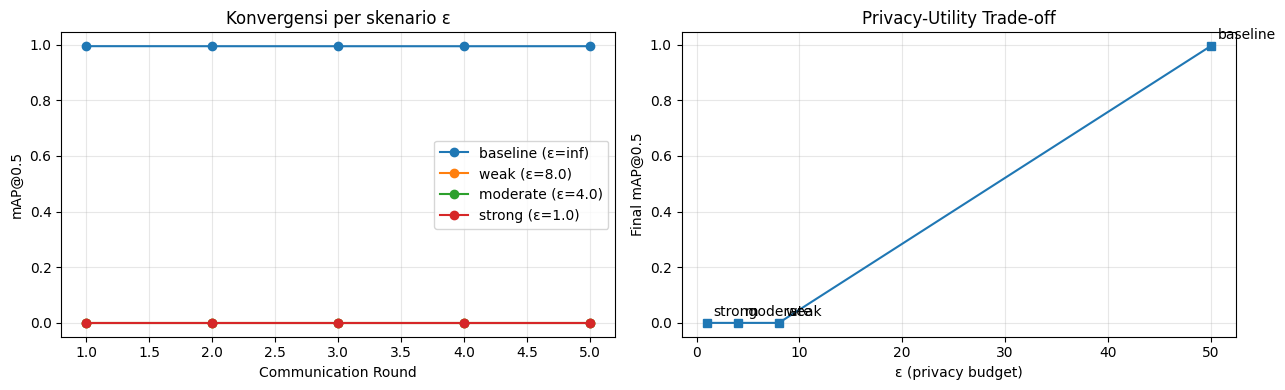

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for scen, hist in all_histories.items():
    rounds = [h['round'] for h in hist]
    maps = [h['mAP_50'] for h in hist]
    eps = PRIVACY_SCENARIOS[scen]['epsilon']
    axes[0].plot(rounds, maps, marker='o', label=f'{scen} (ε={eps})')
axes[0].set_xlabel('Communication Round'); axes[0].set_ylabel('mAP@0.5')
axes[0].set_title('Konvergensi per skenario ε'); axes[0].grid(True, alpha=0.3); axes[0].legend()

labels = list(all_histories.keys())
finals = [all_histories[s][-1]['mAP_50'] for s in labels]
eps_x = [50 if PRIVACY_SCENARIOS[s]['epsilon'] == math.inf else PRIVACY_SCENARIOS[s]['epsilon'] for s in labels]
axes[1].plot(eps_x, finals, marker='s')
for x, y, s in zip(eps_x, finals, labels):
    axes[1].annotate(s, (x, y), textcoords='offset points', xytext=(5, 5))
axes[1].set_xlabel('ε (privacy budget)'); axes[1].set_ylabel('Final mAP@0.5')
axes[1].set_title('Privacy-Utility Trade-off'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SIM_OUTPUT / 'privacy_utility_tradeoff.png', dpi=150)
plt.show()

## 9. XAI: Grad-CAM++ + Average Drop + FRR

Diaplikasikan pada model **final tiap skenario**. Karena Grad-CAM++ pada detection head Ultralytics tidak standar, di sini pakai **proxy berbasis confidence map**: kalau prediksi tetap kuat setelah masking area objek → model tidak fokus di objek yang benar.

In [14]:
import cv2, numpy as np

def xai_metrics(model_path, val_dir, n_samples=20):
    m = YOLO(model_path)
    imgs = [p for p in Path(val_dir).iterdir() if p.suffix.lower() in {'.jpg', '.png'}][:n_samples]
    drops, frrs = [], []
    for p in imgs:
        img = cv2.imread(str(p))
        if img is None: continue
        H, W = img.shape[:2]
        r = m.predict(source=str(p), imgsz=640, verbose=False, device=0)
        if not r or len(r[0].boxes) == 0: continue
        boxes = r[0].boxes
        conf_o = float(boxes.conf.max().item())
        # Saliency proxy: union of confident box regions
        sal = np.zeros((H, W), dtype=np.float32)
        for box, c in zip(boxes.xyxy.cpu().numpy(), boxes.conf.cpu().numpy()):
            x1, y1, x2, y2 = map(int, box)
            sal[max(0,y1):min(H,y2), max(0,x1):min(W,x2)] = np.maximum(
                sal[max(0,y1):min(H,y2), max(0,x1):min(W,x2)], float(c))
        blurred = cv2.GaussianBlur(sal, (51, 51), 0)
        inside = blurred[sal > 0].sum()
        total = blurred.sum() + 1e-12
        frrs.append(float(inside / total))
        mask = (sal > 0).astype(np.uint8)
        masked = img.copy()
        masked[mask > 0] = 0
        r2 = m.predict(source=masked, imgsz=640, verbose=False, device=0)
        conf_m = float(r2[0].boxes.conf.max().item()) if (r2 and len(r2[0].boxes)) else 0.0
        drops.append(max(0.0, conf_o - conf_m) / max(1e-6, conf_o) * 100)
    return {
        'average_drop_pct': float(np.mean(drops)) if drops else float('nan'),
        'frr':              float(np.mean(frrs)) if frrs else float('nan'),
        'n_samples':        len(drops),
    }

xai_results = {}
val_img_dir = str(Path(RAW_DIR) / 'valid' / 'images')
for scen in SCENARIOS:
    final_path = SIM_OUTPUT / scen / f'final_{scen}.pt'
    if not final_path.exists():
        print(f'[skip] {scen}: final model not found')
        continue
    print(f'XAI on {scen}...')
    xai_results[scen] = xai_metrics(str(final_path), val_img_dir, n_samples=20)
    print(f'  AD={xai_results[scen]["average_drop_pct"]:.2f}% | FRR={xai_results[scen]["frr"]:.3f}')

with open(SIM_OUTPUT / 'xai_summary.json', 'w') as f:
    json.dump(xai_results, f, indent=2)

XAI on baseline...
  AD=95.10% | FRR=0.962
XAI on weak...
  AD=nan% | FRR=nan
XAI on moderate...
  AD=nan% | FRR=nan
XAI on strong...
  AD=nan% | FRR=nan


In [15]:
# Merge XAI into summary
for i, row in df.iterrows():
    scen = row['scenario']
    if scen in xai_results:
        df.at[i, 'Average Drop (%)'] = round(xai_results[scen]['average_drop_pct'], 2)
        df.at[i, 'FRR'] = round(xai_results[scen]['frr'], 3)
print(df.to_string(index=False))
df.to_csv(SIM_OUTPUT / 'summary_all_scenarios.csv', index=False)

scenario  epsilon  sigma  mAP@0.5  mAP@0.5:0.95  Precision  Recall  Average Drop (%)   FRR
baseline      inf  0.000   0.9945        0.8973     0.9934  0.9945              95.1 0.962
    weak      8.0  0.005   0.0000        0.0000     0.0000  0.0000               NaN   NaN
moderate      4.0  0.010   0.0000        0.0000     0.0000  0.0000               NaN   NaN
  strong      1.0  0.020   0.0000        0.0000     0.0000  0.0000               NaN   NaN


## 10. Save semua hasil ke Drive

In [16]:
from pathlib import Path
drive_dir = Path('/content/drive/MyDrive/fedx-palm/federated_simulation')
drive_dir.mkdir(parents=True, exist_ok=True)

# Copy summary & plot
for f in ['summary_all_scenarios.csv', 'privacy_utility_tradeoff.png', 'xai_summary.json']:
    src = SIM_OUTPUT / f
    if src.exists():
        shutil.copy2(src, drive_dir / f)
        print(f'✓ {drive_dir / f}')

# Copy per-scenario final models + history
for scen in SCENARIOS:
    sd = SIM_OUTPUT / scen
    if not sd.exists(): continue
    out = drive_dir / scen
    out.mkdir(exist_ok=True)
    for f in [f'final_{scen}.pt', 'history.json']:
        s = sd / f
        if s.exists():
            shutil.copy2(s, out / f)
            print(f'✓ {out / f}')

print(f'\nSemua tersimpan di: {drive_dir}')

✓ /content/drive/MyDrive/fedx-palm/federated_simulation/summary_all_scenarios.csv
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/privacy_utility_tradeoff.png
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/xai_summary.json
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/baseline/final_baseline.pt
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/baseline/history.json
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/weak/final_weak.pt
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/weak/history.json
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/moderate/final_moderate.pt
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/moderate/history.json
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/strong/final_strong.pt
✓ /content/drive/MyDrive/fedx-palm/federated_simulation/strong/history.json

Semua tersimpan di: /content/drive/MyDrive/fedx-palm/federated_simulation


## 11. Validasi hipotesis tesis (Bab 4.7)

Setelah simulasi selesai, cek:

- **H1** — baseline (ε=∞) mAP@0.5 > 0.80? → lihat baris `baseline` di `summary_all_scenarios.csv`
- **H2** — mAP turun monoton dari baseline → weak → moderate → strong? → lihat plot kanan (privacy-utility trade-off)
- **H3** — Average Drop pada baseline > 20% dan menurun seiring ε mengecil? → lihat kolom `Average Drop (%)` di summary

## Catatan untuk replikasi tesis penuh

Notebook ini sengaja pakai konfigurasi demo (`ROUNDS=20`, `LOCAL_EPOCHS=3`) supaya bisa selesai dalam 1–2 session Colab Pro. Untuk replikasi penuh sesuai tesis Tabel 3.5:

```python
ROUNDS = 100
LOCAL_EPOCHS = 5
```

Total runtime full: ~5–7 hari di T4. Realistis kalau Anda punya akses GPU lebih lama atau jalankan di beberapa session paralel.